In [1]:
# Cell 1: Imports and parameters
import os
os.environ['JAX_PLATFORMS'] = 'cpu'  # Force JAX to use CPU

import jax
import jax.numpy as jnp
from jax.experimental.ode import odeint
import numpy as np

# Verify we're using CPU
print(f"JAX backend: {jax.default_backend()}")
print(f"Available devices: {jax.devices()}")


JAX backend: cpu
Available devices: [CpuDevice(id=0)]


In [2]:

# System size and mass
N = 5   # number of masses
mass = 1.0

# Unpack parameters: p[0:N+1] = k_i (spring stiffnesses), p[N+1:] = beta (Duffing coeffs)
# For N masses, we have N+1 springs: wall-mass0, mass0-mass1, ..., mass(N-2)-mass(N-1), mass(N-1)-wall
def unpack_params(p):
    k_springs = p[:N+1]  # N+1 spring constants
    beta = p[N+1:]       # N Duffing coefficients
    return k_springs, beta

In [3]:
# Cell 2: Forcing and system dynamics
def forcing(t):
    # sinusoidal drive on mass index 0
    return 1.*jnp.array([jnp.sin(2.0 * t)] + [0.0] * (N - 1))

def dynamics(state, t, p):
    # state = [x_0, ..., x_{N-1}, v_0, ..., v_{N-1}]
    x, v = jnp.split(state, 2)
    k_springs, beta = unpack_params(p)

    # fixed‐end springs → pad x with zeros at both ends
    x_pad = jnp.concatenate([jnp.array([0.0]), x, jnp.array([0.0])])
    
    # linear spring forces with individual spring constants
    # For mass i: force = -k[i]*(x[i] - x[i-1]) - k[i+1]*(x[i] - x[i+1])
    Kx = jnp.zeros_like(x)
    for i in range(N):
        # Left spring force: -k_springs[i] * (x[i] - x_pad[i])
        # Right spring force: -k_springs[i+1] * (x[i] - x_pad[i+2])
        Kx = Kx.at[i].set(k_springs[i] * (x_pad[i] - x[i]) + k_springs[i+1] * (x_pad[i+2] - x[i]))
    
    # local Duffing nonlinearity
    duff = -0*beta * x**3
    # acceleration
    a = ( Kx + duff + forcing(t) ) / mass

    return jnp.concatenate([v, a])





In [4]:
# Cell 3: Create a synthetic “true” trajectory
# Parameters: [k_0, k_1, ..., k_N, beta_0, beta_1, ..., beta_{N-1}]
# N+1 spring constants + N Duffing coefficients
p_true = jnp.array([1.0] * (N+1) + [0.5] * N)   # true parameters
print(f"Parameter vector length: {len(p_true)} (expected: {2*N+1})")
print(f"Spring constants: {p_true[:N+1]}")
print(f"Duffing coefficients: {p_true[N+1:]}")
t_final = 10.0
num_steps = 200
ts = jnp.linspace(0.0, t_final, num_steps)
init_state = jnp.zeros(2 * N)

# forward integrate to get target
target_states = odeint(dynamics, init_state, ts, p_true, rtol=1e-12, atol=1e-12)
target_traj  = target_states[:, N-1]    # record last mass’s position
print("Target trajectory shape:", target_traj.shape)

Parameter vector length: 11 (expected: 11)
Spring constants: [1. 1. 1. 1. 1. 1.]
Duffing coefficients: [0.5 0.5 0.5 0.5 0.5]
Target trajectory shape: (200,)


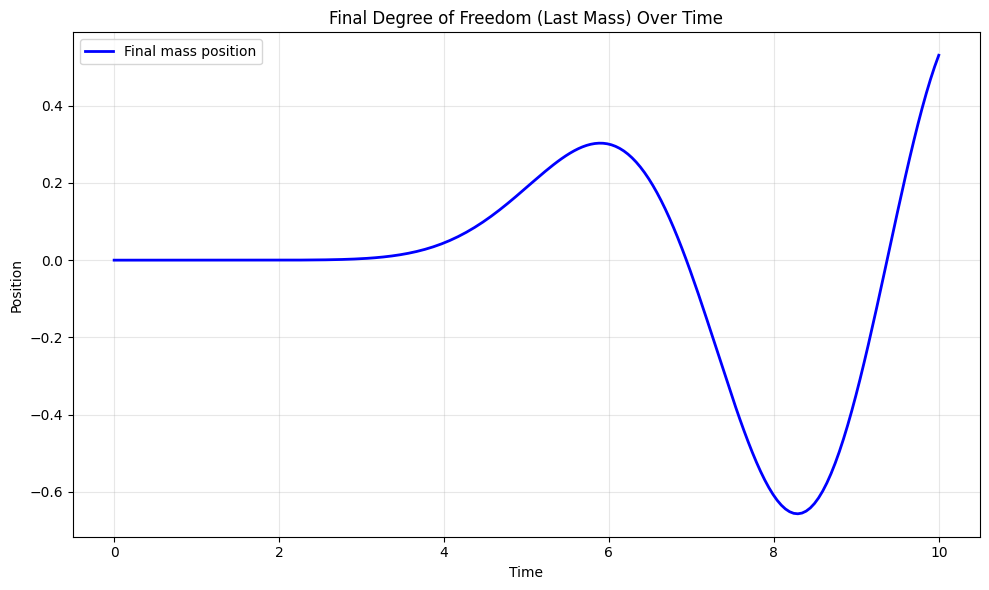

Final mass trajectory range: [-0.6571, 0.5308]


In [5]:
# Cell 5: Plot the final DOF over time
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(ts, target_traj, 'b-', linewidth=2, label='Final mass position')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Final Degree of Freedom (Last Mass) Over Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final mass trajectory range: [{target_traj.min():.4f}, {target_traj.max():.4f}]")


In [6]:
# Cell 4: Define and evaluate the loss
def loss_fn(p):
    states = odeint(dynamics, init_state, ts, p)
    x_end  = states[:, N-1]
    return 0.5 * jnp.trapezoid((x_end - target_traj)**2, ts)

p_test = p_true * 1.1
print("Loss at p_test:", loss_fn(p_test))


Loss at p_test: 0.10088164


In [7]:
# Cell 7: Compute the adjoint‐based gradient

# (a) replay forward trajectory at p_test
states = odeint(dynamics, init_state, ts, p_test)

# (b) interpolation helper for target_traj
def target_interp(t):
    return jnp.interp(t, ts, target_traj)

# (c) interpolation helper for state trajectory
def state_interp(t, states_traj):
    # Interpolate each component of the state vector
    state_components = []
    for i in range(states_traj.shape[1]):
        component = jnp.interp(t, ts, states_traj[:, i])
        state_components.append(component)
    return jnp.array(state_components)

# (d) running‐cost gradient: ∇_u g = (x_end - target) on DOF N-1
def running_cost_grad(state, t):
    x, v = jnp.split(state, 2)
    gx = jnp.zeros_like(x).at[N-1].set(x[N-1] - target_interp(t))
    gv = jnp.zeros_like(v)
    return jnp.concatenate([gx, gv])  # gradient wrt [x, v] = [∇_x g, 0]

# (e) Jacobian of dynamics wrt state
jac_dyn = jax.jacfwd(dynamics, argnums=0)

# (f) adjoint ODE: da/dt = -J^T a - ∇g
def adjoint_ode(a, t, p, states_traj):
    u = state_interp(t, states_traj)
    J = jac_dyn(u, t, p)
    return (J.T @ a) + running_cost_grad(u, t)

# integrate adjoint backward in time
# For backward integration, we need to reverse time: τ = T - t
T = t_final
def adjoint_ode_reversed(a, tau, p, states_traj):
    t = T - tau  # convert back to forward time
    return adjoint_ode(a, t, p, states_traj)  # negative because we're going backward

tau_span = jnp.linspace(0.0, T, num_steps)  # τ goes from 0 to T
aT = jnp.zeros(2 * N)  # terminal condition a(T) = 0

# Integrate backward
a_rev = odeint(lambda a, tau: adjoint_ode_reversed(a, tau, p_test, states), 
               aT, tau_span, rtol=1e-12, atol=1e-12)

# Convert back to forward time order
a_traj = a_rev[::-1]

print("Adjoint trajectory shape:", a_traj.shape)
print("Forward states shape:", states.shape)

Adjoint trajectory shape: (200, 10)
Forward states shape: (200, 10)


In [8]:
# Cell 8: Form the gradient integral and compare to autodiff

# (f) Jacobian of dynamics wrt parameters
jac_params = jax.jacfwd(dynamics, argnums=2)

# build overlap integrand a^T ∂_p f for the adjoint gradient formula
ints = []
for a, u, t in zip(a_traj, states, ts):
    Jp = jac_params(u, t, p_test)            # shape (2N, num_params)
    ints.append((a[:, None].T @ Jp)[0])      # (1, num_params) -> (num_params,)
ints = jnp.stack(ints)                       # (num_steps, num_params)

# gradient from adjoint formula: ∇_p J = ∫ a^T ∂f/∂p dt
grad_adjoint = jnp.trapezoid(ints, ts, axis=0)
print("Adjoint gradient:", grad_adjoint)

# autodiff for verification
grad_auto = jax.grad(loss_fn)(p_test)
print("Autodiff gradient:", grad_auto)

print("\nDifference:", grad_adjoint - grad_auto)
print("Relative error:", jnp.abs(grad_adjoint - grad_auto) / (jnp.abs(grad_auto) + 1e-8))

# Normalized gradient comparisons and overlaps
def normalize_gradient(grad):
    norm = jnp.linalg.norm(grad)
    return grad / (norm + 1e-12)  # add small epsilon to avoid division by zero

grad_adjoint_norm = normalize_gradient(grad_adjoint)
grad_auto_norm = normalize_gradient(grad_auto)

print("\n--- Normalized Gradient Analysis ---")
print("Adjoint gradient (normalized):", grad_adjoint_norm)
print("Autodiff gradient (normalized):", grad_auto_norm)
print("Normalized difference:", grad_adjoint_norm - grad_auto_norm)
print("Normalized difference norm:", jnp.linalg.norm(grad_adjoint_norm - grad_auto_norm))

# Compute overlap (dot product) between normalized gradients
overlap = jnp.dot(grad_adjoint_norm, grad_auto_norm)
print(f"\nOverlap (Adjoint · Autodiff): {overlap:.8f}")
print(f"Overlap percentage: {overlap * 100:.6f}%")

# Additional angle information
angle_rad = jnp.arccos(jnp.clip(overlap, -1.0, 1.0))
angle_deg = angle_rad * 180.0 / jnp.pi
print(f"Angle between gradients: {angle_deg:.6f} degrees")

if overlap > 0.999:
    print("✓ Excellent agreement: gradients are nearly identical in direction")
elif overlap > 0.99:
    print("✓ Very good agreement: gradients point in very similar directions")
elif overlap > 0.9:
    print("✓ Good agreement: gradients point in similar directions")
else:
    print("⚠ Poor agreement: gradients have significant directional differences")

Adjoint gradient: [0.25759754 0.30047312 0.38556096 0.38556013 0.30047247 0.25760004
 0.         0.         0.         0.         0.        ]
Autodiff gradient: [0.25766087 0.3005747  0.3856703  0.38567254 0.30057317 0.25765875
 0.         0.         0.         0.         0.        ]

Difference: [-6.33299351e-05 -1.01566315e-04 -1.09344721e-04 -1.12414360e-04
 -1.00702047e-04 -5.87105751e-05  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00]
Relative error: [0.00024579 0.00033791 0.00028352 0.00029148 0.00033503 0.00022786
 0.         0.         0.         0.         0.        ]

--- Normalized Gradient Analysis ---
Adjoint gradient (normalized): [0.32965884 0.3845286  0.49341926 0.4934182  0.38452777 0.32966205
 0.         0.         0.         0.         0.        ]
Autodiff gradient (normalized): [0.32964396 0.3845467  0.4934156  0.49341846 0.38454476 0.32964125
 0.         0.         0.         0.         0.        ]
Normalized difference: [ 1.487135

In [9]:
def dynamics_time_mirror_forcing(state, t, p):
    # state = [x_0, ..., x_{N-1}, v_0, ..., v_{N-1}]
    x, v = jnp.split(state, 2)
    k_springs, beta = unpack_params(p)

    # fixed‐end springs → pad x with zeros at both ends
    x_pad = jnp.concatenate([jnp.array([0.0]), x, jnp.array([0.0])])
    
    # linear spring forces with individual spring constants
    # For mass i: force = -k[i]*(x[i] - x[i-1]) - k[i+1]*(x[i] - x[i+1])
    Kx = jnp.zeros_like(x)
    for i in range(N):
        # Left spring force: -k_springs[i] * (x[i] - x_pad[i])
        # Right spring force: -k_springs[i+1] * (x[i] - x_pad[i+2])
        Kx = Kx.at[i].set(k_springs[i] * (x_pad[i] - x[i]) + k_springs[i+1] * (x_pad[i+2] - x[i]))
    
    # local Duffing nonlinearity
    duff = -0*beta * x**3
    # acceleration
    a = ( Kx + duff + forcing(T-t)) / mass

    return jnp.concatenate([v, a])

In [10]:
# Cell 14: Test time reversal property of mirrored dynamics

print("=== Testing Time Reversal Property ===")

# 1. Forward dynamics (already computed as 'states')
print("Forward dynamics from t=0 to t=T:")
print(f"  Initial state u(0): {init_state}")
print(f"  Final state u(T): {states[-1]}")

# 2. Run w_dynamics with epsilon=0 (pure time reversal)

def w_dynamics_test(w, t, p):
    """w_dynamics with epsilon=0 for time reversal test"""
    base = dynamics_time_mirror_forcing(w, t, p)
    return base 

# Initial condition for w: w(0) = [x(T), -v(T)]
w0_test = states[-1].copy()
w0_test = jnp.concatenate([w0_test[0:N], -w0_test[N:]])  # flip velocities

print(f"\nMirrored dynamics from t=0 to t=T:")
print(f"  Initial state w(0): {w0_test}")

# Integrate mirrored dynamics
w_states_test = odeint(w_dynamics_test, w0_test, ts, p_test)

v_test = w_states_test[:, :N] - states[::-1][:, :N]

# Set print options to show all entries without truncation
jnp.set_printoptions(threshold=jnp.inf, linewidth=200)
print("v_states shape:", v_test.shape)
print("v_states full array:")
print(v_test)
# Reset print options to default
jnp.set_printoptions(threshold=1000, linewidth=75)

print(f"  Final state w(T): {w_states_test[-1]}")

# 3. Check time reversal property
# If true time reversal: w(T) should equal [x(0), -v(0)] = [0, -0] = [0, 0]
expected_final = jnp.concatenate([init_state[0:N], -init_state[N:]])
actual_final = w_states_test[-1]

print(f"\nTime reversal check:")
print(f"  Expected w(T): {expected_final}")
print(f"  Actual w(T): {actual_final}")
print(f"  Difference: {actual_final - expected_final}")
print(f"  Difference norm: {jnp.linalg.norm(actual_final - expected_final):.6e}")

# Check if we have good time reversal (within numerical precision)
reversal_error = jnp.linalg.norm(actual_final - expected_final)
if reversal_error < 1e-6:
    print("✓ Excellent time reversal: w_dynamics is the true time reverse!")
elif reversal_error < 1e-3:
    print("✓ Good time reversal: w_dynamics approximates time reverse well")
else:
    print("⚠ Poor time reversal: significant discrepancy detected")


=== Testing Time Reversal Property ===
Forward dynamics from t=0 to t=T:
  Initial state u(0): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Final state u(T): [-0.90596396  0.29289252 -0.28641742 -0.41117537  0.6876043   0.12652008
 -1.0822221   1.2019418  -0.24937671 -0.08972757]

Mirrored dynamics from t=0 to t=T:
  Initial state w(0): [-0.90596396  0.29289252 -0.28641742 -0.41117537  0.6876043  -0.12652008
  1.0822221  -1.2019418   0.24937671  0.08972757]
v_states shape: (200, 5)
v_states full array:
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-5.96046448e-08  3.57627869e-07 -3.27825546e-07  2.38418579e-07  2.38418579e-07]
 [-2.98023224e-07  5.96046448e-07 -1.28149986e-06  2.98023224e-07 -4.17232513e-07]
 [ 1.19209290e-07  1.19209290e-07  2.98023224e-08  2.98023224e-08 -1.78813934e-07]
 [ 0.00000000e+00  3.27825546e-07 -2.38418579e-07  2.38418579e-07 -2.38418579e-07]
 [ 2.38418579e-07  3.87430191e-07 -4.76837158e-07  4.76837158e-07 -2.98023224e-07]
 [ 9.

=== Time Reversal Visualization ===


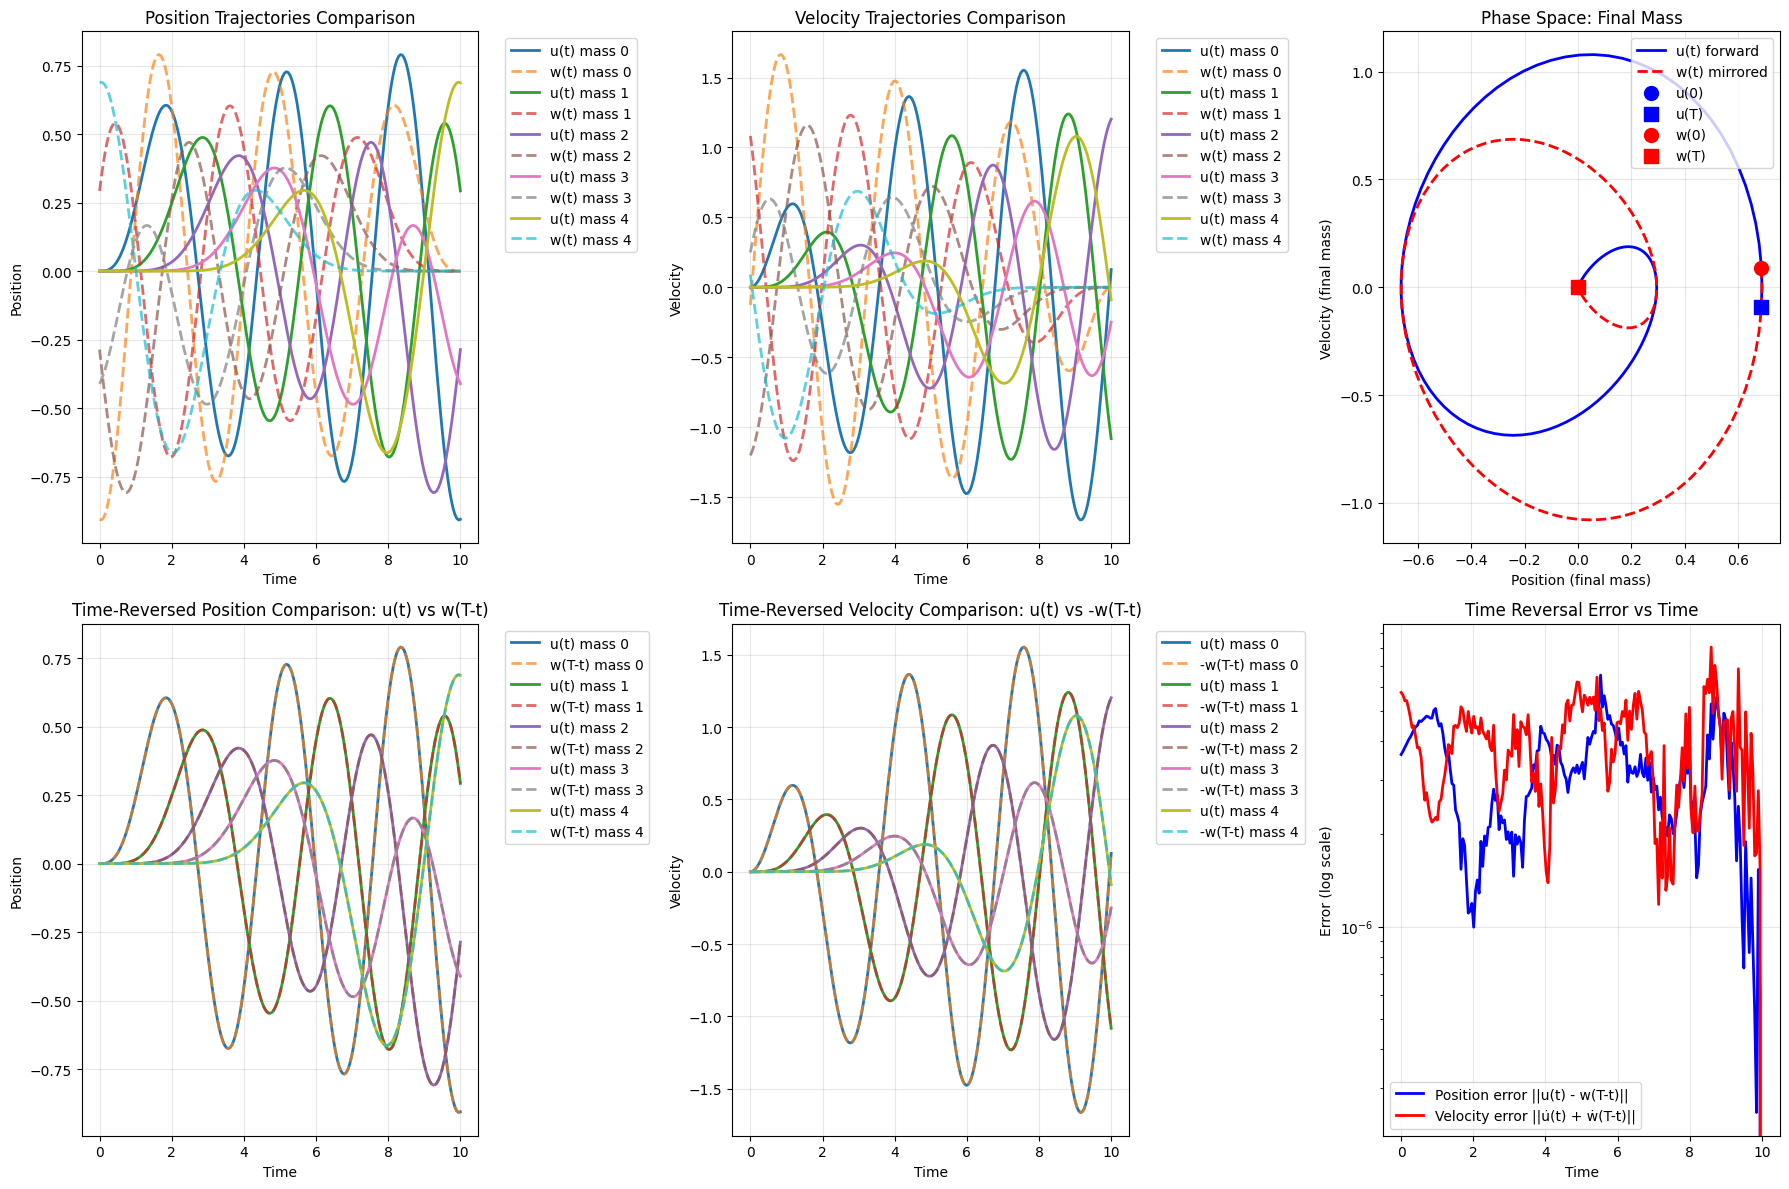


=== Time Reversal Error Analysis ===
Maximum position error: 6.557296e-06
Maximum velocity error: 8.083643e-06
Mean position error: 3.101226e-06
Mean velocity error: 3.873406e-06
Final state error: 6.802820e-06

Energy conservation check:
Forward dynamics energy variation: 1.226927e+00
Mirrored dynamics energy variation: 1.226927e+00
Energy difference between systems: 3.839411e+00


In [11]:
# Cell 15: Visualize time reversal comparison

print("=== Time Reversal Visualization ===")

# Extract positions and velocities for plotting
u_positions = states[:, :N]  # Forward dynamics positions
u_velocities = states[:, N:]  # Forward dynamics velocities

w_positions = w_states_test[:, :N]  # Mirrored dynamics positions  
w_velocities = w_states_test[:, N:]  # Mirrored dynamics velocities

# Create comparison plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Position trajectories for all masses
ax = axes[0, 0]
for i in range(N):
    ax.plot(ts, u_positions[:, i], '-', linewidth=2, label=f'u(t) mass {i}')
    ax.plot(ts, w_positions[:, i], '--', linewidth=2, alpha=0.7, label=f'w(t) mass {i}')
ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_title('Position Trajectories Comparison')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# Plot 2: Velocity trajectories for all masses
ax = axes[0, 1]
for i in range(N):
    ax.plot(ts, u_velocities[:, i], '-', linewidth=2, label=f'u(t) mass {i}')
    ax.plot(ts, w_velocities[:, i], '--', linewidth=2, alpha=0.7, label=f'w(t) mass {i}')
ax.set_xlabel('Time')
ax.set_ylabel('Velocity')
ax.set_title('Velocity Trajectories Comparison')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# Plot 3: Phase space trajectory for final mass
ax = axes[0, 2]
ax.plot(u_positions[:, -1], u_velocities[:, -1], 'b-', linewidth=2, label='u(t) forward')
ax.plot(w_positions[:, -1], w_velocities[:, -1], 'r--', linewidth=2, label='w(t) mirrored')
ax.scatter(u_positions[0, -1], u_velocities[0, -1], color='blue', s=100, marker='o', label='u(0)', zorder=5)
ax.scatter(u_positions[-1, -1], u_velocities[-1, -1], color='blue', s=100, marker='s', label='u(T)', zorder=5)
ax.scatter(w_positions[0, -1], w_velocities[0, -1], color='red', s=100, marker='o', label='w(0)', zorder=5)
ax.scatter(w_positions[-1, -1], w_velocities[-1, -1], color='red', s=100, marker='s', label='w(T)', zorder=5)
ax.set_xlabel('Position (final mass)')
ax.set_ylabel('Velocity (final mass)')
ax.set_title('Phase Space: Final Mass')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Time-reversed comparison - positions
ax = axes[1, 0]
# Plot u(t) vs w(T-t) to check if w is time-reversed u
for i in range(N):
    ax.plot(ts, u_positions[:, i], '-', linewidth=2, label=f'u(t) mass {i}')
    ax.plot(ts, w_positions[::-1, i], '--', linewidth=2, alpha=0.7, label=f'w(T-t) mass {i}')
ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_title('Time-Reversed Position Comparison: u(t) vs w(T-t)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# Plot 5: Time-reversed comparison - velocities (should be negated)
ax = axes[1, 1]
for i in range(N):
    ax.plot(ts, u_velocities[:, i], '-', linewidth=2, label=f'u(t) mass {i}')
    ax.plot(ts, -w_velocities[::-1, i], '--', linewidth=2, alpha=0.7, label=f'-w(T-t) mass {i}')
ax.set_xlabel('Time')
ax.set_ylabel('Velocity')
ax.set_title('Time-Reversed Velocity Comparison: u(t) vs -w(T-t)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# Plot 6: Error analysis
ax = axes[1, 2]
# Compute position and velocity errors as functions of time
pos_error = jnp.linalg.norm(u_positions - w_positions[::-1], axis=1)
vel_error = jnp.linalg.norm(u_velocities + w_velocities[::-1], axis=1)  # Note: + because velocities should be negated

ax.semilogy(ts, pos_error, 'b-', linewidth=2, label='Position error ||u(t) - w(T-t)||')
ax.semilogy(ts, vel_error, 'r-', linewidth=2, label='Velocity error ||u̇(t) + ẇ(T-t)||')
ax.set_xlabel('Time')
ax.set_ylabel('Error (log scale)')
ax.set_title('Time Reversal Error vs Time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Time Reversal Error Analysis ===")
print(f"Maximum position error: {jnp.max(pos_error):.6e}")
print(f"Maximum velocity error: {jnp.max(vel_error):.6e}")
print(f"Mean position error: {jnp.mean(pos_error):.6e}")
print(f"Mean velocity error: {jnp.mean(vel_error):.6e}")
print(f"Final state error: {reversal_error:.6e}")

# Check energy conservation (should be conserved in both systems)
def compute_energy(state, p):
    """Compute total energy (kinetic + potential)"""
    x, v = jnp.split(state, 2)
    k_springs, beta = unpack_params(p)
    
    # Kinetic energy
    KE = 0.5 * mass * jnp.sum(v**2)
    
    # Potential energy from springs
    x_pad = jnp.concatenate([jnp.array([0.0]), x, jnp.array([0.0])])
    PE_spring = 0.0
    for i in range(N+1):
        spring_stretch = x_pad[i+1] - x_pad[i]
        PE_spring += 0.5 * k_springs[i] * spring_stretch**2
    
    # Potential energy from Duffing nonlinearity
    PE_duffing = jnp.sum(0.25 * beta * x**4)
    
    return KE + PE_spring + PE_duffing

# Compute energies along trajectories
energies_u = jnp.array([compute_energy(state, p_test) for state in states])
energies_w = jnp.array([compute_energy(state, p_test) for state in w_states_test])

print(f"\nEnergy conservation check:")
print(f"Forward dynamics energy variation: {jnp.std(energies_u):.6e}")
print(f"Mirrored dynamics energy variation: {jnp.std(energies_w):.6e}")
print(f"Energy difference between systems: {jnp.abs(energies_u[0] - energies_w[0]):.6e}")


In [12]:
v_states-v_test

NameError: name 'v_states' is not defined

In [28]:
v_states_half - v_test

Array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [-6.86645508e-05, -5.36441803e-07, -9.89437103e-06,
        -1.83582306e-05, -4.18424606e-05],
       [-6.71148300e-05, -3.27825546e-07, -1.31726265e-05,
        -1.82688236e-05, -4.29153442e-05],
       [-6.72340393e-05, -1.40070915e-06, -1.42753124e-05,
        -1.94311142e-05, -4.29749489e-05],
       [-6.68168068e-05, -3.33786011e-06, -1.69277191e-05,
        -2.02357769e-05, -4.13060188e-05],
       [-6.58631325e-05, -5.21540642e-06, -1.91926956e-05,
        -2.01761723e-05, -4.14252281e-05],
       [-6.48498535e-05, -5.72204590e-06, -2.19941139e-05,
        -2.03847885e-05, -4.05311584e-05],
       [-6.24656677e-05, -9.00030136e-06, -2.33650208e-05,
        -2.05338001e-05, -3.90410423e-05],
       [-6.15715981e-05, -1.16825104e-05, -2.43782997e-05,
        -2.08616257e-05, -3.59416008e-05],
       [-8.30292702e-05, -1.54376030e-05, -3.92198563e-05,
        -2.03996897e-05

In [27]:
# Cell 10: ε-rule as a function with gradient comparisons

def compute_eps_gradient(epsilon):
    """Compute gradient using ε-rule for given epsilon value"""
    # For pure running cost problems (no terminal cost):
    # w(0) = u(0) (same initial condition - no terminal cost perturbation)
    # Initial condition for w: w(0) = [x(T), -v(T)]
    w0 = states[-1].copy()
    w0 = jnp.concatenate([w0[0:N], -w0[N:]])  # flip velocities

    # Define modified dynamics: dw/dt = f(w,t,p) + ε·∇g(w,t) 
    def w_dynamics(w, t, p):
        base = dynamics_time_mirror_forcing(w, t, p)
        u = state_interp(T-t, states)
        rung = running_cost_grad(u, T-t)   # ∇g at each time
        return base + 0.0*epsilon * rung

    # Integrate the perturbed system forward
    w_states = odeint(w_dynamics, w0, ts, p_test)

    # Extract the difference v = w - u
    v_states_half = w_states[:, :N] - states[::-1][:, :N]
    v_states = w_states - states[::-1]
    
    # Set print options to show all entries without truncation
    jnp.set_printoptions(threshold=jnp.inf, linewidth=200)
    print("v_states shape:", v_states.shape)
    print("v_states full array:")
    print(v_states)
    # Reset print options to default
    jnp.set_printoptions(threshold=1000, linewidth=75)
    

    # Gradient via ε-rule: ∇_p J = (1/ε) * ∫ v^T * ∂f/∂p dt
    ints = []
    for v, u, t in zip(v_states[::-1], states, ts):
        Jp = jax.jacfwd(dynamics, argnums=2)(u, t, p_test)  # ∂f/∂p
        ints.append((v[:, None].T @ Jp)[0])
    ints = jnp.stack(ints)

    grad_eps =    jnp.trapezoid(ints, ts, axis=0)
    return grad_eps, v_states_half

# Test the function and compare gradients
eps = 0.00
grad_eps, v_states_half = compute_eps_gradient(eps)

print("ε-rule gradient:", grad_eps)
print("Adjoint gradient:", grad_adjoint)
print("Autodiff gradient:", grad_auto)

print("\nε-rule vs Adjoint difference:", grad_eps - grad_adjoint)
print("ε-rule vs Autodiff difference:", grad_eps - grad_auto)

# Compute normalized gradients
def normalize_grad(grad):
    norm = jnp.linalg.norm(grad)
    return grad / (norm + 1e-12)  # add small epsilon to avoid division by zero

grad_eps_norm = normalize_grad(grad_eps)
grad_adjoint_norm = normalize_grad(grad_adjoint)
grad_auto_norm = normalize_grad(grad_auto)

print("\n--- Normalized Gradient Comparisons ---")
print("ε-rule normalized:", grad_eps_norm)
print("Adjoint normalized:", grad_adjoint_norm)
print("Autodiff normalized:", grad_auto_norm)

print("\nNormalized ε-rule vs Adjoint difference:", grad_eps_norm - grad_adjoint_norm)
print("Normalized ε-rule vs Autodiff difference:", grad_eps_norm - grad_auto_norm)
print("Normalized Adjoint vs Autodiff difference:", grad_adjoint_norm - grad_auto_norm)

# Dot products to check directional similarity
print("\n--- Directional Similarity (Dot Products) ---")
print("ε-rule · Adjoint:", jnp.dot(grad_eps_norm, grad_adjoint_norm))
print("ε-rule · Autodiff:", jnp.dot(grad_eps_norm, grad_auto_norm))
print("Adjoint · Autodiff:", jnp.dot(grad_adjoint_norm, grad_auto_norm))


v_states shape: (200, 10)
v_states full array:
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00 -2.53040165e-01  2.16444421e+00 -2.40388370e+00  4.98753428e-01  1.79455131e-01]
 [-6.87241554e-05 -1.78813934e-07 -1.02221966e-05 -1.81198120e-05 -4.16040421e-05  7.25051984e-02  1.95850468e+00 -2.34339595e+00  6.29355431e-01 -1.75930634e-02]
 [-6.74128532e-05  2.68220901e-07 -1.44541264e-05 -1.79708004e-05 -4.33325768e-05  3.98071438e-01  1.73540378e+00 -2.26265144e+00  7.49912620e-01 -2.12797195e-01]
 [-6.71148300e-05 -1.28149986e-06 -1.42455101e-05 -1.94013119e-05 -4.31537628e-05  7.20372438e-01  1.49749172e+00 -2.16245747e+00  8.59437704e-01 -4.04742062e-01]
 [-6.68168068e-05 -3.01003456e-06 -1.71661377e-05 -1.99973583e-05 -4.15444374e-05  1.03615952e+00  1.24726582e+00 -2.04371572e+00  9.57067609e-01 -5.92053950e-01]
 [-6.56247139e-05 -4.82797623e-06 -1.96695328e-05 -1.96993351e-05 -4.17232513e-05  1.34226120e+00  9.87317801e-01 -1.90751243e+00  1.04207

In [ ]:
# Cell 11: Epsilon sweep and log-log plots

# Define range of epsilon values (logarithmically spaced)
epsilons = jnp.linspace(1e-4, 1e0, 10)  # from 1e-6 to 1e-1
print(f"Testing {len(epsilons)} epsilon values from {epsilons[0]:.1e} to {epsilons[-1]:.1e}")

# Compute gradients for each epsilon
eps_gradients = []
for i, eps in enumerate(epsilons):
    print(f"Computing gradient {i+1}/{len(epsilons)} for ε = {eps:.1e}", end='\r')
    grad = compute_eps_gradient(eps)
    eps_gradients.append(grad)

eps_gradients = jnp.array(eps_gradients)
print(f"\nCompleted gradient computations. Shape: {eps_gradients.shape}")

# Compute errors (differences from autodiff)
errors_raw = jnp.linalg.norm(eps_gradients - grad_auto[None, :], axis=1)
errors_normalized = []

for grad_eps in eps_gradients:
    # Normalize both gradients
    grad_eps_norm = grad_eps / (jnp.linalg.norm(grad_eps) + 1e-12)
    grad_auto_norm = grad_auto / (jnp.linalg.norm(grad_auto) + 1e-12)
    # Compute normalized error
    error_norm = jnp.linalg.norm(grad_eps_norm - grad_auto_norm)
    errors_normalized.append(error_norm)

errors_normalized = jnp.array(errors_normalized)

print(f"Raw errors range: {errors_raw.min():.2e} to {errors_raw.max():.2e}")
print(f"Normalized errors range: {errors_normalized.min():.2e} to {errors_normalized.max():.2e}")


In [ ]:
errors_normalized

In [ ]:
# Cell 12: Create log-log plots

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Raw (non-normalized) errors
ax1.loglog(epsilons, errors_raw, 'bo-', linewidth=2, markersize=6, label='ε-rule vs Autodiff')
ax1.loglog(epsilons, epsilons, 'k--', alpha=0.7, label='ε (linear reference)')
ax1.loglog(epsilons, epsilons**2, 'r--', alpha=0.7, label='ε² (quadratic reference)')
ax1.set_xlabel('ε (epsilon)', fontsize=12)
ax1.set_ylabel('||∇ε - ∇autodiff||', fontsize=12)
ax1.set_title('Raw Gradient Error vs ε', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Normalized errors
ax2.loglog(epsilons, errors_normalized, 'ro-', linewidth=2, markersize=6, label='Normalized ε-rule vs Autodiff')
ax2.loglog(epsilons, epsilons, 'k--', alpha=0.7, label='ε (linear reference)')
ax2.loglog(epsilons, epsilons**2, 'g--', alpha=0.7, label='ε² (quadratic reference)')
ax2.set_xlabel('ε (epsilon)', fontsize=12)
ax2.set_ylabel('||∇ε/||∇ε|| - ∇auto/||∇auto|| ||', fontsize=12)
ax2.set_title('Normalized Gradient Error vs ε', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Find optimal epsilon values
min_raw_idx = jnp.argmin(errors_raw)
min_norm_idx = jnp.argmin(errors_normalized)

print(f"\nOptimal ε for raw error: {epsilons[min_raw_idx]:.2e} (error: {errors_raw[min_raw_idx]:.2e})")
print(f"Optimal ε for normalized error: {epsilons[min_norm_idx]:.2e} (error: {errors_normalized[min_norm_idx]:.2e})")

# Check convergence rate for small epsilon
small_eps_mask = epsilons < 1e-3
if jnp.sum(small_eps_mask) > 3:
    small_epsilons = epsilons[small_eps_mask]
    small_errors = errors_raw[small_eps_mask]
    
    # Fit log(error) = a + b*log(epsilon) to find convergence rate
    log_eps = jnp.log(small_epsilons)
    log_err = jnp.log(small_errors)
    
    # Simple linear regression
    A = jnp.vstack([log_eps, jnp.ones(len(log_eps))]).T
    slope, intercept = jnp.linalg.lstsq(A, log_err, rcond=None)[0]
    
    print(f"\nFor small ε, error ∝ ε^{slope:.2f} (slope = {slope:.2f})")
    if jnp.abs(slope - 1) < 0.1:
        print("→ Linear convergence confirmed!")
    elif jnp.abs(slope - 2) < 0.1:
        print("→ Quadratic convergence confirmed!")
